# Gen AI Bootcamp Day 2 – AI Product Intelligence System
## Tasks 1, 2 & 3: Smart Recommendations | Unique Catalog | Reverse Search

> **Dataset required:** Add [Fashion Product Images (Small)](https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small) to this notebook before running.
>
> **Run order:** Execute cells top-to-bottom. The embedding cell (~2 min) must complete before the task cells.

## 📦 Setup & Installations

In [1]:
!pip install -q transformers torch torchvision sentence-transformers faiss-cpu pillow pandas matplotlib seaborn scikit-learn ipywidgets
print("✅ Packages installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 103.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 87.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 

## 📥 Imports

In [2]:
import os, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from tqdm.notebook import tqdm
import torch
from transformers import CLIPProcessor, CLIPModel
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Ready! Using device: {device}')


✅ Ready! Using device: cuda


## 📂 Load Dataset + CLIP Model + Compute Embeddings
> ⚠️ This cell takes ~2–3 minutes on GPU (T4). Run it once and proceed to the tasks below.

In [3]:
import glob

def find_dataset():
    matches = glob.glob('/kaggle/input/**/styles.csv', recursive=True)
    if matches:
        csv = Path(matches[0])
        images = csv.parent / 'images'
        print(f'✅ Found dataset at: {csv.parent}')
        return csv, images
    raise FileNotFoundError('Add the Fashion Product Images (Small) dataset.')

CSV_PATH, IMAGES_PATH = find_dataset()

df = pd.read_csv(CSV_PATH, on_bad_lines='skip')
df['image_path'] = df['id'].apply(lambda x: IMAGES_PATH / f'{x}.jpg')
df = df[df['image_path'].apply(lambda p: p.exists())].reset_index(drop=True)

SAMPLE_SIZE = 500
df_sample = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=42).reset_index(drop=True)
print(f'✅ Loaded {len(df_sample)} products')

print('Loading CLIP model...')
clip_model     = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(device)
clip_processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
clip_model.eval()
print('✅ CLIP ready!')

def _extract_tensor(out):
    """Extract the embedding tensor regardless of what transformers version returns.
    Kaggle returns BaseModelOutputWithPooling — the CLIP projection output
    is stored in .pooler_output (shape 1x512).
    Normal transformers returns a plain Tensor directly.
    """
    if isinstance(out, torch.Tensor):
        return out
    # BaseModelOutputWithPooling — use pooler_output (the projected embedding)
    if hasattr(out, 'pooler_output') and out.pooler_output is not None:
        return out.pooler_output
    # Last resort: CLS token of last hidden state
    if hasattr(out, 'last_hidden_state'):
        return out.last_hidden_state[:, 0, :]
    raise ValueError(f"Cannot extract tensor from {type(out)}")

def get_image_embedding(image_path):
    img    = Image.open(image_path).convert('RGB')
    inputs = clip_processor(images=img, return_tensors='pt').to(device)
    with torch.no_grad():
        out = clip_model.get_image_features(**inputs)
    feat = _extract_tensor(out).to(torch.float32).squeeze(0)   # (512,)
    norm = feat.norm().item()
    if norm < 1e-6:
        return None
    return (feat / norm).cpu().numpy()

def get_text_embedding(text):
    inputs = clip_processor(
        text=[text], return_tensors='pt', padding=True, truncation=True
    ).to(device)
    with torch.no_grad():
        out = clip_model.get_text_features(**inputs)
    feat = _extract_tensor(out).to(torch.float32).squeeze(0)   # (512,)
    norm = feat.norm().item()
    return (feat / (norm + 1e-8)).cpu().numpy()

# ── Quick sanity check on ONE image before processing all 500 ──
_test = get_image_embedding(df_sample.iloc[0]['image_path'])
if _test is None:
    raise RuntimeError("Embedding still failing — check model output.")
print(f"✅ Single-image test passed — embedding shape: {_test.shape}, norm: {np.linalg.norm(_test):.4f}")

print('\nComputing image embeddings (this may take 1–2 min)...')
good_rows, good_embs = [], []
for orig_idx, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
    emb = get_image_embedding(row['image_path'])
    if emb is not None:
        good_rows.append(orig_idx)
        good_embs.append(emb)

df_sample  = df_sample.loc[good_rows].reset_index(drop=True)
embeddings = np.stack(good_embs, axis=0).astype(np.float32)

print(f'✅ Embeddings ready: {embeddings.shape}  (dropped {500 - len(good_embs)} bad images)')
sims0 = embeddings @ embeddings[0]
top5  = sorted(sims0, reverse=True)[:5]
print(f'   Top-5 cosine sims for item[0]: {[f"{s:.3f}" for s in top5]}')
print(f'   Expected: 1.000, then 0.80–0.95 for same-category items')


✅ Found dataset at: /kaggle/input/datasets/paramaggarwal/fashion-product-images-small


✅ Loaded 500 products
Loading CLIP model...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

✅ CLIP ready!
✅ Single-image test passed — embedding shape: (512,), norm: 1.0000

Computing image embeddings (this may take 1–2 min)...


  0%|          | 0/500 [00:00<?, ?it/s]

✅ Embeddings ready: (500, 512)  (dropped 0 bad images)
   Top-5 cosine sims for item[0]: ['1.000', '0.976', '0.958', '0.957', '0.956']
   Expected: 1.000, then 0.80–0.95 for same-category items


---
# 🎯 Task 1 — Smart Product Recommendation Engine
Search for any product and get **similar** and **complementary** recommendations.

**How it works:**
- **Similar**: Uses CLIP image embeddings + cosine similarity to find visually alike products within the same article type.
- **Complementary**: A curated category map defines which types "go with" the query. Within those types, items are ranked by cosine similarity.
- **Match %**: Cosine similarity mapped to 0–100% scale. ~90%+ = very similar; ~70% = different category.

In [4]:
# ─────────────────────────────────────────────────────────────
# TASK 1 — Smart Product Recommendation Engine
# SIMILAR:       CLIP image cosine similarity within same article type
# COMPLEMENTARY: Category map selects candidates; ranked by cosine sim
# Score:         Raw cosine similarity × 100  (same-item ≈ 90–100%)
# ─────────────────────────────────────────────────────────────

COMPLEMENTARY_MAP = {
    'Shirts':      ['Jeans', 'Trousers', 'Belts', 'Watches', 'Shoes'],
    'Tshirts':     ['Jeans', 'Trousers', 'Shorts', 'Belts', 'Shoes'],
    'Shoes':       ['Socks', 'Belts', 'Trousers', 'Jeans'],
    'Casual Shoes':['Socks', 'Jeans', 'Shorts'],
    'Sports Shoes':['Socks', 'Shorts', 'Tshirts'],
    'Topwear':     ['Jeans', 'Trousers', 'Belts', 'Watches', 'Shoes'],
    'Bottomwear':  ['Shirts', 'Tshirts', 'Belts', 'Shoes'],
    'Watches':     ['Wallets', 'Belts', 'Shirts', 'Sunglasses'],
    'Bags':        ['Wallets', 'Belts', 'Watches'],
    'Socks':       ['Shoes', 'Shorts'],
    'Belts':       ['Trousers', 'Jeans', 'Shirts'],
    'Wallets':     ['Belts', 'Watches', 'Bags'],
    'Jeans':       ['Shirts', 'Tshirts', 'Belts', 'Shoes', 'Watches'],
    'Trousers':    ['Shirts', 'Belts', 'Shoes', 'Watches'],
    'Shorts':      ['Tshirts', 'Shoes', 'Socks'],
    'Innerwear':   ['Shorts', 'Tshirts'],
    'Sunglasses':  ['Shirts', 'Watches', 'Bags'],
    'Sandals':     ['Shorts', 'Trousers'],
    'Heels':       ['Bags', 'Belts'],
    'Flats':       ['Bags', 'Jeans'],
}

def sim_to_pct(sim_val):
    """Cosine similarity of L2-normalised CLIP vectors is in [-1, 1].
    For fashion images: same item≈0.95–1.0, same category≈0.75–0.92,
    cross-category≈0.15–0.35.  Clamp to [0,1] then × 100."""
    return float(np.clip(float(sim_val), 0.0, 1.0)) * 100.0

def get_recommendations(query_idx, top_k=4, mode='complementary'):
    query_emb = embeddings[query_idx]
    raw_sims  = (embeddings @ query_emb).astype(np.float64)
    raw_sims[query_idx] = -999

    query_row     = df_sample.iloc[query_idx]
    query_article = str(query_row.get('articleType', '')).strip()
    query_subcat  = str(query_row.get('subCategory', '')).strip()

    if mode == 'similar':
        mask = (df_sample['articleType'].str.strip() == query_article).values
        mask[query_idx] = False
        if mask.sum() < top_k:
            mask = (df_sample['subCategory'].str.strip() == query_subcat).values
            mask[query_idx] = False
        candidates = np.where(mask)[0]
        if len(candidates) == 0:
            candidates = np.arange(len(df_sample))
    else:
        comp_types = []
        for key, values in COMPLEMENTARY_MAP.items():
            if key.lower() in query_article.lower() or key.lower() in query_subcat.lower():
                comp_types.extend(values)
        comp_types = list(set(comp_types))
        if comp_types:
            mask = df_sample['articleType'].apply(
                lambda t: any(c.lower() in str(t).lower() for c in comp_types)
            ).values
        else:
            mask = (df_sample['articleType'].str.strip() != query_article).values
        mask[query_idx] = False
        candidates = np.where(mask)[0]
        if len(candidates) == 0:
            candidates = np.arange(len(df_sample))

    ranked = candidates[np.argsort(raw_sims[candidates])[::-1]][:top_k]
    return ranked, raw_sims[ranked]

def visualize_recommendations(query_idx, mode='complementary'):
    top_idx, top_sims = get_recommendations(query_idx, mode=mode)
    query_row = df_sample.iloc[query_idx]
    n = 1 + len(top_idx)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
    if n == 1:
        axes = [axes]

    all_idx    = [query_idx] + list(top_idx)
    all_labels = ['🔍 QUERY'] + [f'#{j+1}  ({sim_to_pct(s):.1f}% match)' for j, s in enumerate(top_sims)]
    all_colors = ['gold'] + (['#4CAF50'] if mode == 'complementary' else ['#2196F3']) * len(top_idx)

    for ax, idx, label, color in zip(axes, all_idx, all_labels, all_colors):
        row = df_sample.iloc[idx]
        ax.imshow(Image.open(row['image_path']))
        name = str(row['productDisplayName'])
        name = name if len(name) <= 22 else name[:20] + '…'
        ax.set_title(f"{label}\n{name}\n[{row['articleType']}]", fontsize=8.5)
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
        ax.axis('off')

    mode_label = 'Complementary (items that go with it)' if mode == 'complementary' else 'Similar (visually alike)'
    plt.suptitle(f'Task 1 – {mode_label}\nQuery: {query_row["productDisplayName"]}',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ── WIDGET UI ──
t1_search_box  = widgets.Text(placeholder='e.g. blue shirt, watch, shoes, jeans',
                               description='Product:', layout=widgets.Layout(width='50%'))
t1_search_btn  = widgets.Button(description='🔍 Search', button_style='primary')
t1_product_dd  = widgets.Dropdown(description='Pick product:', layout=widgets.Layout(width='70%'))
t1_show_btn    = widgets.Button(description='✅ Show Recommendations', button_style='success')
t1_out         = widgets.Output()
t1_matches_box = widgets.VBox([])

def t1_do_search(b):
    term = t1_search_box.value.strip()
    with t1_out:
        clear_output()
    if not term:
        with t1_out:
            print('⚠️ Please enter a search term.')
        return
    matches = df_sample[df_sample['productDisplayName'].str.contains(term, case=False, na=False)]
    if len(matches) == 0:
        with t1_out:
            print('❌ No products found. Try: shirt, watch, shoes, jeans, bag')
        t1_matches_box.children = []
        return
    options = [(f"{row['productDisplayName']}  [{row['articleType']}]  (idx {idx})", idx)
               for idx, row in matches.iterrows()]
    t1_product_dd.options = options
    t1_matches_box.children = [t1_product_dd, t1_show_btn]
    with t1_out:
        print(f'Found {len(matches)} products — pick one below:')

def t1_do_recommend(b):
    idx = t1_product_dd.value
    with t1_out:
        clear_output()
        print('Generating recommendations…')
        visualize_recommendations(idx, mode='complementary')
        visualize_recommendations(idx, mode='similar')

t1_search_btn.on_click(t1_do_search)
t1_show_btn.on_click(t1_do_recommend)

print('━' * 60)
print('🎯  TASK 1 — Smart Product Recommendation Engine')
print('━' * 60)
print('ℹ️  Match % = CLIP cosine similarity × 100')
print('   Same item ≈ 90–100% | Same category ≈ 75–90% | Cross-category ≈ 15–35%')
display(widgets.VBox([widgets.HBox([t1_search_box, t1_search_btn]), t1_matches_box, t1_out]))


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🎯  TASK 1 — Smart Product Recommendation Engine
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ℹ️  Match % = CLIP cosine similarity × 100
   Same item ≈ 90–100% | Same category ≈ 75–90% | Cross-category ≈ 15–35%


---
# 🗂️ Task 2 — Unique Product Catalog Creation
Find and group duplicate products, then browse the clean catalog.

**How it works:**
- CLIP image embeddings are clustered with **KMeans** (150 clusters).
- Within each cluster the product closest to the centroid is chosen as the **canonical** (representative) item.
- Result: ~500 raw products collapse into ~150 unique catalog entries, removing near-duplicates.

Clustering products with KMeans…
✅ 500 products → 150 unique catalog entries
   Duplicates removed: 70%


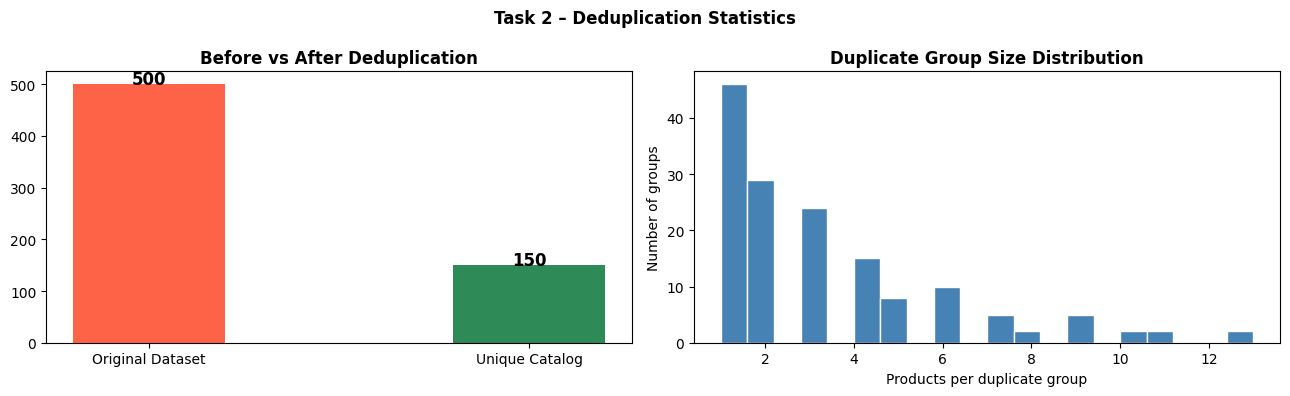

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🗂️   TASK 2 — Duplicate Group Explorer
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [5]:
# ─────────────────────────────────────────────────────────────
# TASK 2 — Unique Product Catalog Creation
# KMeans clusters embeddings → pick centroid-closest as canonical
# ─────────────────────────────────────────────────────────────

print('Clustering products with KMeans…')
N_CLUSTERS = min(150, len(df_sample) // 2)
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)
df_sample = df_sample.copy()
df_sample['cluster'] = cluster_labels

catalog_rows = []
for cid in range(N_CLUSTERS):
    mask         = (df_sample['cluster'] == cid).values
    if mask.sum() == 0:
        continue
    cluster_df   = df_sample[mask].reset_index(drop=True)
    cluster_embs = embeddings[mask]

    # Filter out any zero/NaN rows within the cluster
    valid        = np.isfinite(cluster_embs).all(axis=1) & (np.linalg.norm(cluster_embs, axis=1) > 1e-6)
    if valid.sum() == 0:
        continue
    cluster_embs = cluster_embs[valid]
    cluster_df   = cluster_df[valid].reset_index(drop=True)

    # Normalised centroid → dot product is cosine similarity
    centroid     = cluster_embs.mean(axis=0)
    centroid     = centroid / (np.linalg.norm(centroid) + 1e-8)
    sims         = (cluster_embs @ centroid)           # shape (k,) — no sklearn needed
    canonical    = cluster_df.iloc[int(np.argmax(sims))]

    catalog_rows.append({
        'catalog_id'  : cid,
        'product_name': canonical['productDisplayName'],
        'article_type': canonical['articleType'],
        'sub_category': canonical['subCategory'],
        'base_colour' : canonical['baseColour'],
        'image_path'  : canonical['image_path'],
        'cluster_size': int(mask.sum()),
        'product_id'  : canonical['id'],
    })

catalog_df = pd.DataFrame(catalog_rows).reset_index(drop=True)
print(f'✅ {len(df_sample)} products → {len(catalog_df)} unique catalog entries')
print(f'   Duplicates removed: {1 - len(catalog_df)/len(df_sample):.0%}')

# ── Stats Chart ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
counts = [len(df_sample), len(catalog_df)]
bars = axes[0].bar(['Original Dataset', 'Unique Catalog'], counts,
                   color=['tomato', 'seagreen'], width=0.4)
axes[0].set_title('Before vs After Deduplication', fontweight='bold')
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(val), ha='center', fontweight='bold', fontsize=12)
sizes = catalog_df['cluster_size'].values
axes[1].hist(sizes, bins=20, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Products per duplicate group')
axes[1].set_ylabel('Number of groups')
axes[1].set_title('Duplicate Group Size Distribution', fontweight='bold')
plt.suptitle('Task 2 – Deduplication Statistics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── WIDGET UI ──
t2_search_box = widgets.Text(placeholder='e.g. shirt, watch, shoes, jeans',
                              description='Product:', layout=widgets.Layout(width='50%'))
t2_search_btn = widgets.Button(description='🔍 Find Duplicate Group', button_style='primary')
t2_catalog_dd = widgets.Dropdown(description='Catalog entry:', layout=widgets.Layout(width='80%'))
t2_show_btn   = widgets.Button(description='👀 View Duplicate Group', button_style='success')
t2_out        = widgets.Output()
t2_picker_box = widgets.VBox([])

def t2_do_search(b):
    term = t2_search_box.value.strip()
    with t2_out:
        clear_output()
    if not term:
        return
    match = catalog_df[catalog_df['product_name'].str.contains(term, case=False, na=False)]
    if len(match) == 0:
        with t2_out:
            print('❌ Not found. Try: shirt, watch, shoes, jeans')
        t2_picker_box.children = []
        return
    options = [
        (f"[ID {row['catalog_id']}]  {row['product_name']}  [{row['article_type']}]  — {row['cluster_size']} variants",
         int(row['catalog_id']))
        for _, row in match.iterrows()
    ]
    t2_catalog_dd.options = options
    t2_picker_box.children = [t2_catalog_dd, t2_show_btn]
    with t2_out:
        print(f'Found {len(match)} catalog entries — pick one:')

def t2_do_show_group(b):
    cid   = t2_catalog_dd.value
    group = df_sample[df_sample['cluster'] == cid].head(6).reset_index()
    with t2_out:
        clear_output()
        n = len(group)
        if n == 0:
            print('No products in this cluster.')
            return
        fig, axes = plt.subplots(1, n, figsize=(4*n, 5))
        if n == 1:
            axes = [axes]
        canonical_name = catalog_df[catalog_df['catalog_id'] == cid]['product_name'].values[0]
        # canonical is the first in the cluster (closest to centroid by construction)
        canon_emb = embeddings[df_sample[df_sample['cluster'] == cid].index[0]]
        for i, (ax, (_, row)) in enumerate(zip(axes, group.iterrows())):
            orig_idx = row['index'] if 'index' in row else i
            try:
                sim = float(np.dot(embeddings[orig_idx], canon_emb))
            except Exception:
                sim = 0.0
            pct = float(np.clip(sim, 0, 1)) * 100
            ax.imshow(Image.open(row['image_path']))
            name = str(row['productDisplayName'])
            name = name if len(name) <= 22 else name[:20] + '…'
            label = '⭐ CANONICAL' if i == 0 else f'Variant #{i}  ({pct:.1f}%)' 
            ax.set_title(f'{label}\n{name}', fontsize=8.5)
            for spine in ax.spines.values():
                spine.set_edgecolor('gold' if i == 0 else '#888')
                spine.set_linewidth(3)
            ax.axis('off')
        plt.suptitle(f'Task 2 – Duplicate Group | Canonical: "{canonical_name}" | {len(df_sample[df_sample["cluster"]==cid])} products',
                     fontsize=10, fontweight='bold')
        plt.tight_layout()
        plt.show()

t2_search_btn.on_click(t2_do_search)
t2_show_btn.on_click(t2_do_show_group)

print('━' * 60)
print('🗂️   TASK 2 — Duplicate Group Explorer')
print('━' * 60)
display(widgets.VBox([widgets.HBox([t2_search_box, t2_search_btn]), t2_picker_box, t2_out]))


---
# 🔍 Task 3 — Reverse Product Search (Text → Products)
Type any description and find matching products using CLIP's cross-modal search.

**How it works:**
- CLIP maps both text and images into the **same embedding space**.
- The text query is encoded into a 512-d vector and compared against all image embeddings using **cosine similarity**.
- Top-K most similar products are returned — enabling zero-shot text-to-image retrieval without any training labels.

In [6]:
# ─────────────────────────────────────────────────────────────
# TASK 3 — Reverse Product Search (Text → Products)
# CLIP text and image embeddings share the same space →
# encode text → cosine similarity against all image embeddings
# ─────────────────────────────────────────────────────────────

def text_search(query, top_k=5):
    text_emb = get_text_embedding(query)               # float32 unit vector
    sims     = (embeddings @ text_emb).astype(np.float64)
    top_idx  = np.argsort(sims)[::-1][:top_k]
    return top_idx, sims[top_idx]

def visualize_text_search(query, top_k=5):
    top_idx, top_sims = text_search(query, top_k)
    fig, axes = plt.subplots(1, top_k, figsize=(4*top_k, 5))
    if top_k == 1:
        axes = [axes]
    for rank, (ax, idx, sim) in enumerate(zip(axes, top_idx, top_sims), 1):
        row = df_sample.iloc[idx]
        ax.imshow(Image.open(row['image_path']))
        name = str(row['productDisplayName'])
        name = name if len(name) <= 22 else name[:20] + '…'
        pct  = float(np.clip(sim, 0, 1)) * 100
        ax.set_title(f'#{rank}  ({pct:.1f}% match)\n{name}\n[{row["articleType"]}]', fontsize=8.5)
        for spine in ax.spines.values():
            spine.set_edgecolor('#2196F3')
            spine.set_linewidth(3)
        ax.axis('off')
    plt.suptitle(f'Task 3 – Reverse Text Search: "{query}"', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f'\nTop {top_k} results for "{query}":')
    for rank, (i, s) in enumerate(zip(top_idx, top_sims), 1):
        r   = df_sample.iloc[i]
        pct = float(np.clip(s, 0, 1)) * 100
        print(f'  {rank}. {r["productDisplayName"]}  [{r["articleType"]}]  ({pct:.1f}% match)')

# ── WIDGET UI ──
t3_query_box   = widgets.Text(placeholder='e.g. blue casual shirt, red running shoes, black wallet',
                               description='Query:', layout=widgets.Layout(width='60%'))
t3_topk_slider = widgets.IntSlider(value=5, min=1, max=10, step=1,
                                    description='Top K:', style={'description_width': 'initial'})
t3_search_btn  = widgets.Button(description='🔍 Search Products', button_style='primary')
t3_out         = widgets.Output()

examples = ['blue casual shirt', 'red running shoes', 'black leather wallet', 'silver watch', 'white sneakers']
example_btns = [widgets.Button(description=ex, button_style='info', layout=widgets.Layout(width='auto'))
                for ex in examples]

def t3_do_search(b):
    query = t3_query_box.value.strip()
    if not query:
        with t3_out:
            clear_output()
            print('⚠️ Please enter a search query.')
        return
    with t3_out:
        clear_output()
        print(f'Searching for: "{query}"…')
        visualize_text_search(query, top_k=t3_topk_slider.value)

def make_example_handler(ex):
    def handler(b):
        t3_query_box.value = ex
        t3_do_search(b)
    return handler

t3_search_btn.on_click(t3_do_search)
for btn, ex in zip(example_btns, examples):
    btn.on_click(make_example_handler(ex))

print('━' * 60)
print('🔍  TASK 3 — Reverse Product Search  (Text → Images)')
print('━' * 60)
print('💡 Quick examples (click to try):')
display(widgets.VBox([
    widgets.HBox(example_btns),
    widgets.HBox([t3_query_box, t3_topk_slider]),
    t3_search_btn,
    t3_out
]))


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔍  TASK 3 — Reverse Product Search  (Text → Images)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
💡 Quick examples (click to try):
